# Data Preprocessing & Normalization
Step 1: Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv("students_scored.csv")
df.head()


,student_id,age,program,semester,gpa,attendance,assignments_completion,stress_level,sleep_hours,mental_wellbeing,...,skill_readiness,engagement_score,APS,sleep_score,stress_score,WWS,PTMS,CRS,SRI,Category
0,S001,24,B.Tech,7,6.56,91,89,4,8.7,8,...,7,84,77.90,76.0,60,69.6,33.3,22.0,52.930,Yellow
1,S002,21,B.Sc,7,8.50,91,88,8,8.8,3,...,7,43,87.40,74.0,20,52.4,27.1,12.2,47.790,Red
2,S003,22,B.Sc,6,8.06,83,67,4,8.6,6,...,5,75,78.60,78.0,60,70.8,39.5,19.0,53.930,Yellow
3,S004,24,B.Tech,7,9.26,71,89,4,5.9,4,...,6,45,85.40,68.0,60,64.8,31.0,12.6,51.170,Yellow
4,S005,20,B.Tech,4,7.27,98,50,8,4.1,8,...,3,99,75.75,32.0,20,27.2,38.3,23.4,43.035,Red


Step 2: Select Features for Clustering

In [5]:
features = [
    "attendance",              # attendance %
    "assignments_completion",  # consistency
    "engagement_score",        # engagement
    "APS",                     # academic performance score
    "sleep_score",             # lifestyle
    "stress_score"             # stress indicator
]

X = df[features]


# 2. Apply K-Means Clustering
Step 3: Data Normalization

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Step 4: Find Optimal K (Elbow Method)

D:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

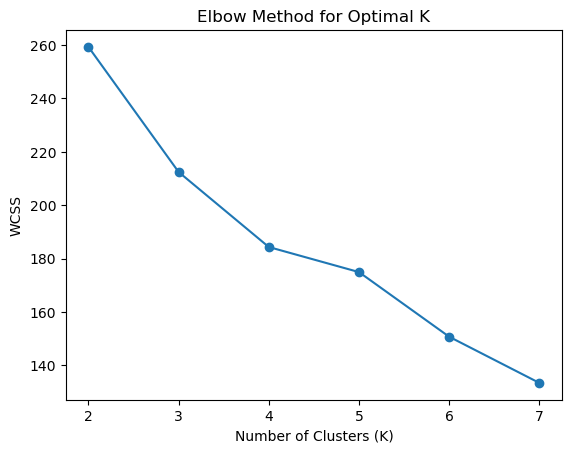

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 8), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


Step 5: Train K-Means Model

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df[["student_id", "Cluster"]].head()


D:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,student_id,Cluster
0,S001,1
1,S002,2
2,S003,1
3,S004,2
4,S005,1


# 3. Cluster Analysis & Interpretation
Step 6: Analyze Cluster Characteristics

In [10]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary


,attendance,assignments_completion,engagement_score,APS,sleep_score,stress_score
Cluster,,,,,,
0,66.875000,77.062500,82.312500,71.318750,84.500000,46.875000
1,90.214286,67.428571,83.714286,77.792857,64.857143,42.857143
2,79.450000,82.000000,53.450000,77.765000,78.400000,36.000000


Step 7: Assign Meaningful Labels to Clusters

In [11]:
cluster_labels = {
    0: "At-Risk Students",
    1: "High Performers",
    2: "Career-Confused Students"
}

df["Cluster_Type"] = df["Cluster"].map(cluster_labels)


# 4. Visualize Clusters
Step 8: PCA for 2D Visualization

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]


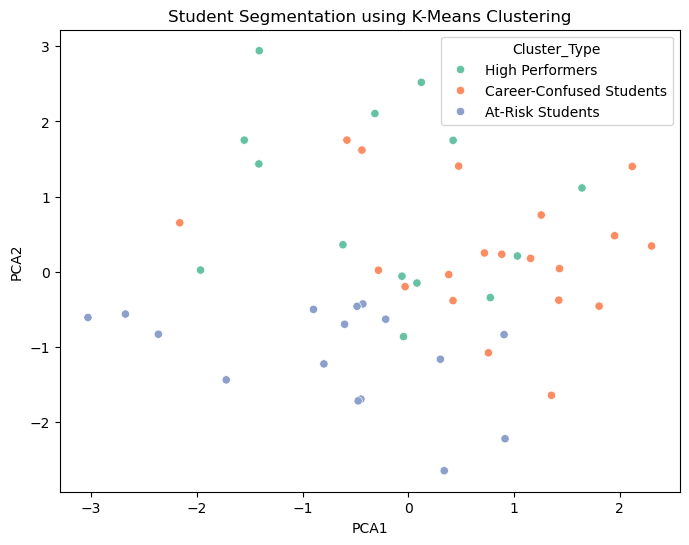

In [13]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster_Type",
    data=df,
    palette="Set2"
)
plt.title("Student Segmentation using K-Means Clustering")
plt.show()


Step 9: Cluster Distribution Plot

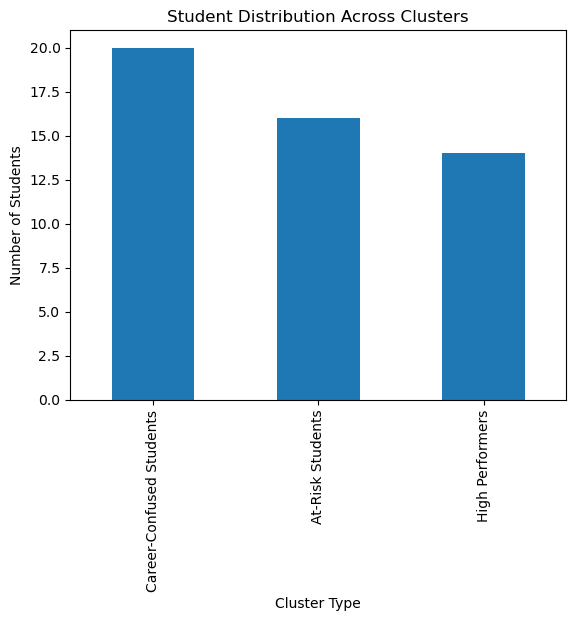

In [14]:
df["Cluster_Type"].value_counts().plot(kind="bar")
plt.title("Student Distribution Across Clusters")
plt.xlabel("Cluster Type")
plt.ylabel("Number of Students")
plt.show()


# 5. Model Validation 
Step 10: Silhouette Score

In [15]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score:", round(sil_score, 3))


Silhouette Score: 0.143


# 6. ML vs Rule-Based Comparison
Step 11: Compare with SRI Category

In [16]:
pd.crosstab(df["Category"], df["Cluster_Type"])


Cluster_Type,At-Risk Students,Career-Confused Students,High Performers
Category,,,
Red,6,13,6
Yellow,10,7,8


In [17]:
df.to_csv("activity3_student_clusters.csv", index=False)
